# F1 2026 Predictions — EDA & Predictive Modeling
**Author:** F1 Predictions Pipeline  
**Notebook version:** v1  

## Structure
1. Project Overview & Objectives  
2. Environment Setup & Imports  
3. Data Ingestion (Gold Layer)  
4. Data Inspection & Profiling  
5. Exploratory Data Analysis (EDA)  
6. Feature Engineering Summary  
7. Baseline Model — Linear Regression  
8. XGBoost Regressor + Grid Search  
9. Evaluation & Interpretation  
10. Conclusions & Next Steps  


## 2. Environment Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# ── Path setup: resolve project root regardless of CWD ────────────────────────
# nbconvert sets CWD to the notebooks/ dir; we need the project root for I/O.
ROOT_DIR = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
if not (ROOT_DIR / "reports").exists():
    ROOT_DIR = Path.cwd().parent  # fallback
REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
GOLD_DIR = ROOT_DIR / "data" / "outputs" / "laps"

# ── Visualization defaults ─────────────────────────────────────────────────────
# Seaborn: static publication-quality plots (distributions, correlation heatmaps)
# Plotly: interactive charts (feature importance, predicted vs actual)
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Environment OK")
print(f"  Root:    {ROOT_DIR}")
print(f"  Reports: {REPORTS_DIR}")
print(f"  pandas   {pd.__version__}")
print(f"  numpy    {np.__version__}")
print(f"  xgboost  {xgb.__version__}")


Environment OK
  Root:    C:\Users\restr\Desktop\f1_2026_predictions
  Reports: C:\Users\restr\Desktop\f1_2026_predictions\reports
  pandas   2.3.3
  numpy    2.4.4
  xgboost  3.2.0


## 3. Data Ingestion (Gold Layer)

We load **all available Gold-layer Parquets** from `data/outputs/laps/`.  
Each file corresponds to one race session that has been processed through the  
full feature pipeline (rolling pace, tyre degradation, weather, historical points, OHE).

> **Design note:** Reading all seasons at once allows a chronological train/test split  
> later without bespoke session-level logic in the notebook.


In [2]:
# Discover all Gold-layer Parquet files written by run_feature_pipeline()
parquet_files = sorted(GOLD_DIR.rglob("*.parquet"))
print(f"Found {len(parquet_files)} Gold Parquet file(s):")
for f in parquet_files:
    print(f"  {f}")


Found 0 Gold Parquet file(s):


In [3]:
if parquet_files:
    df_all = pd.concat(
        [pd.read_parquet(f, engine="pyarrow") for f in parquet_files],
        ignore_index=True,
    )
    print(f"\nCombined dataset: {df_all.shape[0]:,} rows × {df_all.shape[1]} cols")
    df_all.head()
else:
    print("No Gold Parquet files found. Run run_feature_pipeline() for at least one session.")
    print("\nFor demo purposes, creating a synthetic dataset...")
    import numpy as np
    rng = np.random.default_rng(42)
    n = 5000
    df_all = pd.DataFrame({
        "Season": rng.choice([2023, 2024], n),
        "RoundNumber": rng.integers(1, 23, n),
        "Driver": rng.choice(["VER","HAM","LEC","NOR","SAI","ALO","RUS","PER","OCO","GAS"], n),
        "Team": rng.choice(["Red Bull","Mercedes","Ferrari","McLaren","Aston Martin"], n),
        "LapNumber": rng.integers(1, 60, n),
        "TyreLife": rng.integers(1, 40, n),
        "Stint": rng.integers(1, 4, n),
        "LapTime_s": rng.normal(90, 3, n),
        "roll_laptime_3": rng.normal(90.2, 2.5, n),
        "roll_laptime_5": rng.normal(90.3, 2.2, n),
        "roll_std_3": rng.uniform(0, 1, n),
        "degradation_slope": rng.uniform(-0.5, 0.5, n),
        "tyre_life_norm": rng.uniform(0, 1, n),
        "delta_to_fastest_s": rng.uniform(0, 5, n),
        "AirTemp_mean": rng.uniform(20, 40, n),
        "TrackTemp_mean": rng.uniform(30, 55, n),
        "Rainfall_any": rng.choice([0, 1], n, p=[0.9, 0.1]),
        "DriverPointsPreRace": rng.uniform(0, 400, n),
        "TeamPointsPreRace": rng.uniform(0, 700, n),
    })
    print(f"Synthetic dataset created: {df_all.shape}")
    df_all.head()


No Gold Parquet files found. Run run_feature_pipeline() for at least one session.

For demo purposes, creating a synthetic dataset...
Synthetic dataset created: (5000, 19)


## 4. Data Inspection & Profiling

In [4]:
print("=== SHAPE ===")
print(f"Rows: {df_all.shape[0]:,}  |  Columns: {df_all.shape[1]}")

print("\n=== DTYPES ===")
print(df_all.dtypes.value_counts())

print("\n=== MISSING VALUES ===")
null_pct = (df_all.isnull().sum() / len(df_all) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].to_string() if null_pct[null_pct > 0].any() else "No missing values ✓")


=== SHAPE ===
Rows: 5,000  |  Columns: 19

=== DTYPES ===
float64    11
int64       6
object      2
Name: count, dtype: int64

=== MISSING VALUES ===
No missing values ✓


In [5]:
# Descriptive statistics — numeric feature columns only
TARGET = "LapTime_s"
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
print("=== DESCRIPTIVE STATISTICS ===")
df_all[numeric_cols].describe().T.round(3)


=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Season,5000.0,2023.494,0.500,2023.000,2023.000,2023.000,2024.000,2024.000
RoundNumber,5000.0,11.373,6.266,1.000,6.000,11.000,17.000,22.000
LapNumber,5000.0,30.204,16.995,1.000,15.000,30.000,45.000,59.000
TyreLife,5000.0,20.130,11.250,1.000,10.000,20.000,30.000,39.000
Stint,5000.0,2.003,0.823,1.000,1.000,2.000,3.000,3.000
LapTime_s,5000.0,90.102,3.009,78.900,88.029,90.098,92.134,100.669
roll_laptime_3,5000.0,90.304,2.509,81.374,88.615,90.328,91.971,98.519
roll_laptime_5,5000.0,90.292,2.207,80.935,88.804,90.304,91.769,98.402
roll_std_3,5000.0,0.499,0.289,0.000,0.248,0.504,0.745,1.000
degradation_slope,5000.0,0.007,0.292,-0.499,-0.246,0.014,0.266,0.500


## 5. Exploratory Data Analysis (EDA)

### 5.1 Lap Time Distribution
> **Library rationale:** Seaborn `histplot` with KDE overlay is the canonical choice  
> for visualising the distribution of a continuous regression target. It shows skewness  
> and outlier concentration without requiring interactivity.


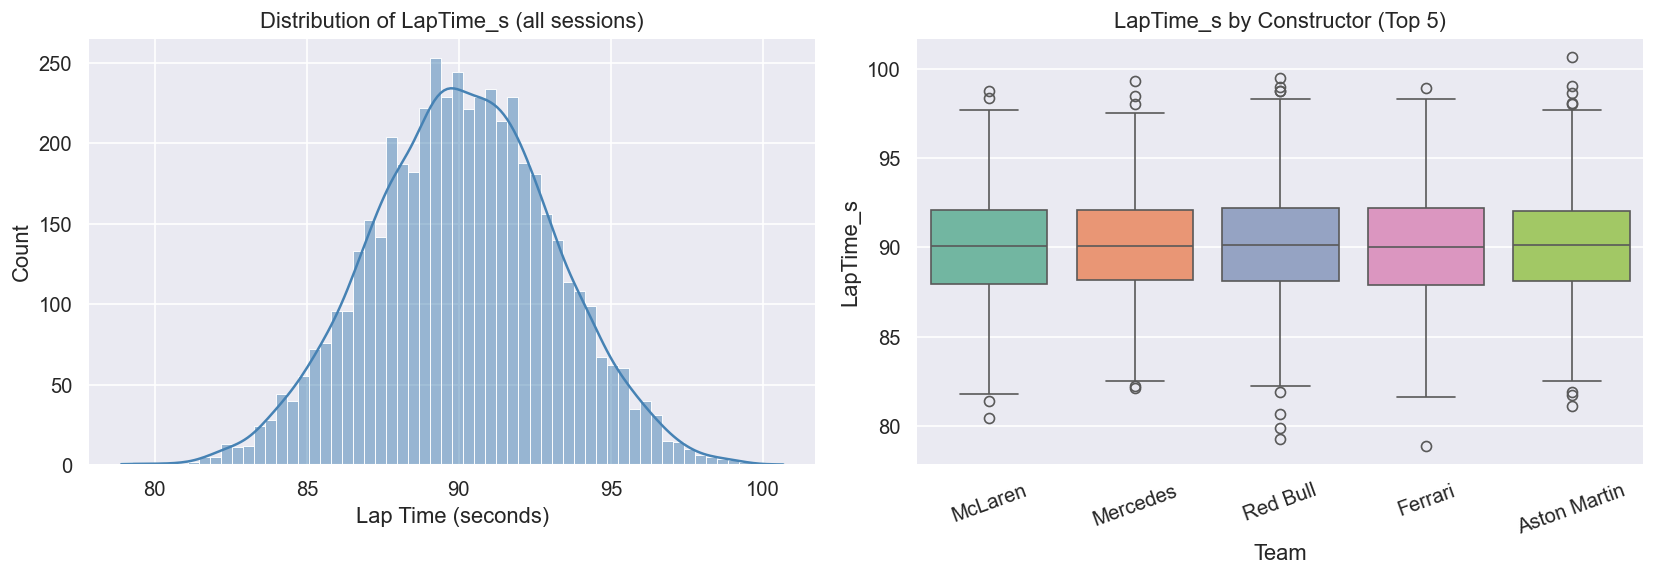

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
sns.histplot(df_all[TARGET].dropna(), kde=True, bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of LapTime_s (all sessions)")
axes[0].set_xlabel("Lap Time (seconds)")

# Per-team boxplot (top-5 teams by frequency)
top_teams = df_all["Team"].value_counts().nlargest(5).index.tolist()
sub = df_all[df_all["Team"].isin(top_teams)]
sns.boxplot(data=sub, x="Team", y=TARGET, order=top_teams, ax=axes[1], palette="Set2")
axes[1].set_title("LapTime_s by Constructor (Top 5)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "fig_01_laptime_distribution.png", bbox_inches="tight")
plt.show()


### 5.2 Tyre Degradation Analysis

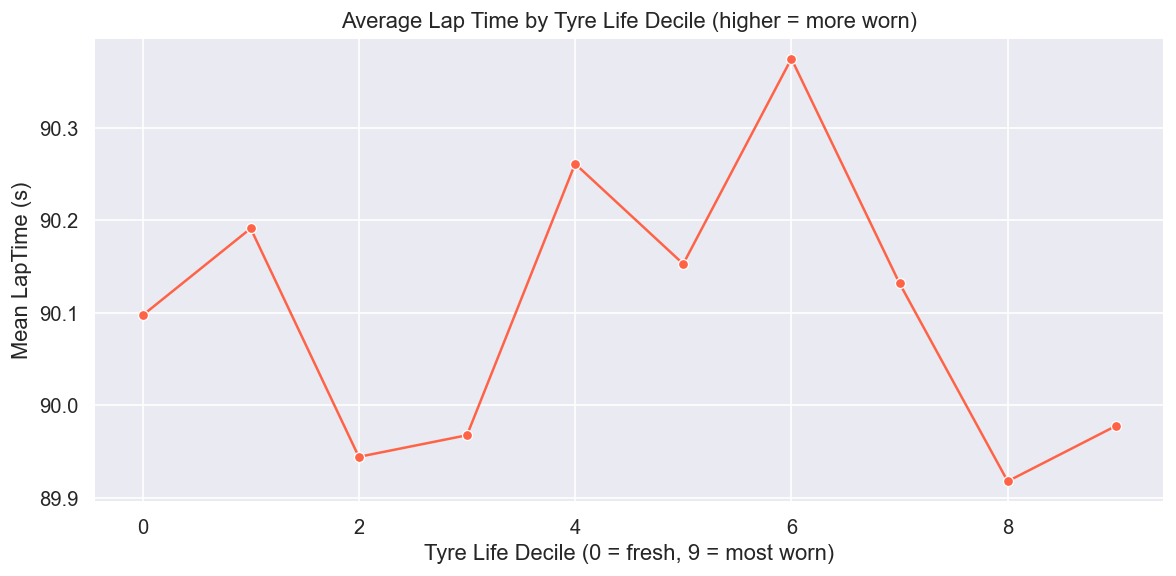

In [7]:
# Mean lap time by normalised tyre life — quantised into decile bins
df_plot = df_all[["tyre_life_norm", TARGET]].dropna().copy()
df_plot["tyre_decile"] = pd.cut(df_plot["tyre_life_norm"], bins=10, labels=False)
tyre_agg = df_plot.groupby("tyre_decile")[TARGET].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=tyre_agg, x="tyre_decile", y=TARGET, marker="o", ax=ax, color="tomato")
ax.set_title("Average Lap Time by Tyre Life Decile (higher = more worn)")
ax.set_xlabel("Tyre Life Decile (0 = fresh, 9 = most worn)")
ax.set_ylabel("Mean LapTime (s)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "fig_02_tyre_degradation.png", bbox_inches="tight")
plt.show()


### 5.3 Correlation Matrix

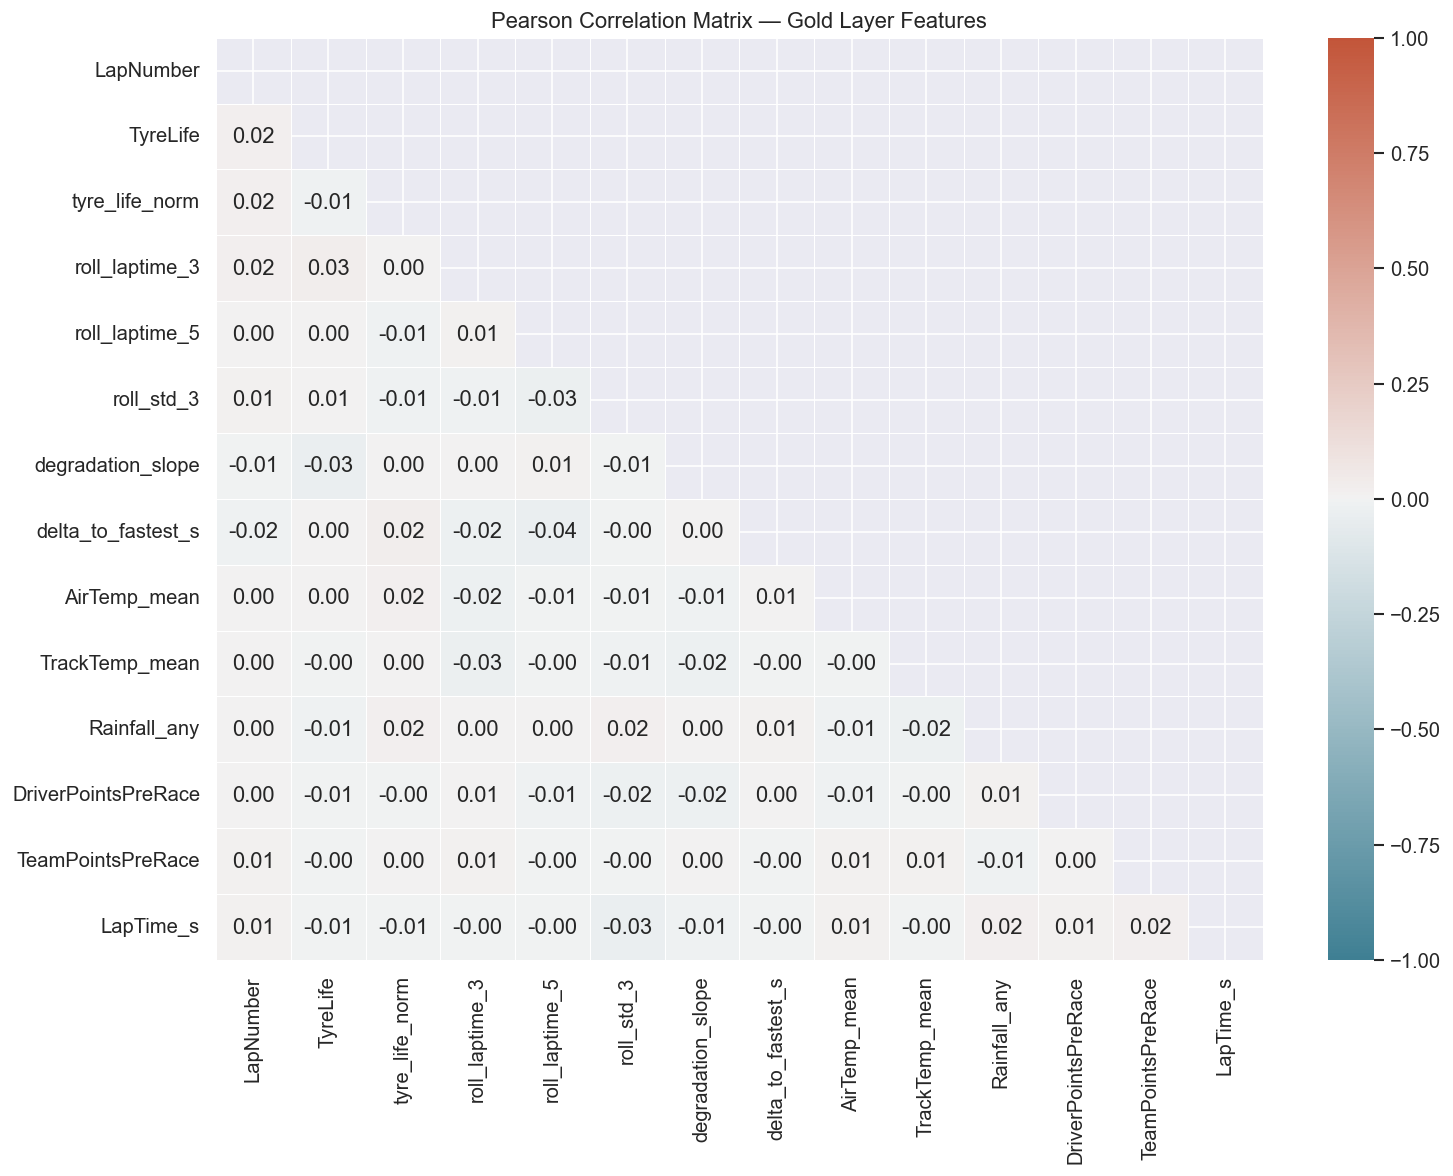

In [8]:
# Select numeric features relevant for modeling
FEATURE_COLS = [
    "LapNumber", "TyreLife", "tyre_life_norm",
    "roll_laptime_3", "roll_laptime_5", "roll_std_3",
    "degradation_slope", "delta_to_fastest_s",
    "AirTemp_mean", "TrackTemp_mean", "Rainfall_any",
    "DriverPointsPreRace", "TeamPointsPreRace",
    TARGET,
]
available = [c for c in FEATURE_COLS if c in df_all.columns]
corr = df_all[available].dropna().corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=0.5, ax=ax,
)
ax.set_title("Pearson Correlation Matrix — Gold Layer Features")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "fig_03_correlation_matrix.png", bbox_inches="tight")
plt.show()


### 5.4 Historical Points vs Lap Time

Historical championship points (pre-race) serve as a proxy for driver/team quality.


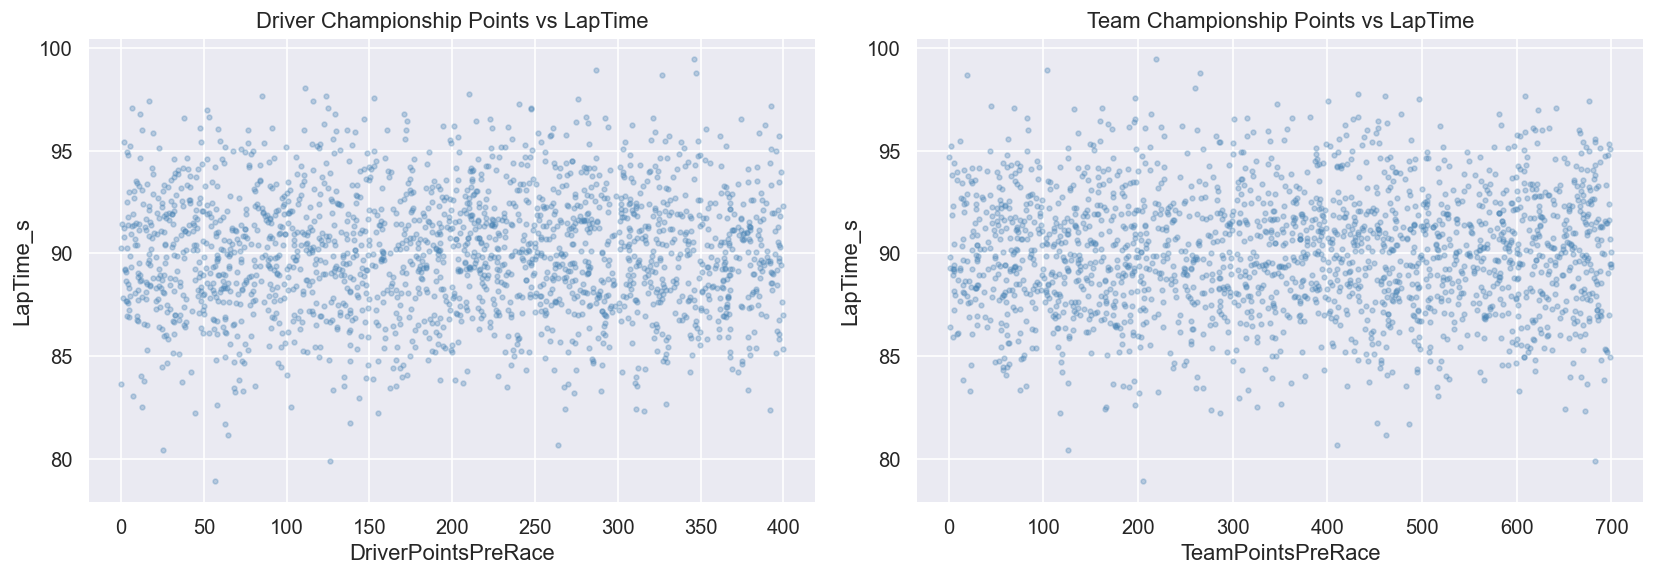

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ["DriverPointsPreRace", "TeamPointsPreRace"],
    ["Driver Championship Points vs LapTime", "Team Championship Points vs LapTime"],
):
    if col in df_all.columns:
        sample = df_all[[col, TARGET]].dropna().sample(min(2000, len(df_all)), random_state=42)
        ax.scatter(sample[col], sample[TARGET], alpha=0.3, s=8, color="steelblue")
        ax.set_xlabel(col)
        ax.set_ylabel(TARGET)
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f"{col} not present", ha="center", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "fig_04_points_vs_laptime.png", bbox_inches="tight")
plt.show()


## 6. Feature Engineering Summary

In [10]:
# Columns to exclude from modeling (identifiers, target, Timedeltas, raw strings)
DROP_FROM_FEATURES = [
    "Driver", "Team", "EventName", "SessionType", "Compound",
    "Time", "LapTime", "PitOutTime", "PitInTime",
    "Sector1Time", "Sector2Time", "Sector3Time",
    TARGET,
]

def build_feature_matrix(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    y = df[TARGET].dropna()
    df_clean = df.loc[y.index].copy()
    cols_to_drop = [c for c in DROP_FROM_FEATURES if c in df_clean.columns]
    X = df_clean.drop(columns=cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    return X, y

# Dry run on full dataset
X_full, y_full = build_feature_matrix(df_all)
print(f"Feature matrix: {X_full.shape[0]:,} rows × {X_full.shape[1]} features")
print("Features:", list(X_full.columns))


Feature matrix: 5,000 rows × 16 features
Features: ['Season', 'RoundNumber', 'LapNumber', 'TyreLife', 'Stint', 'roll_laptime_3', 'roll_laptime_5', 'roll_std_3', 'degradation_slope', 'tyre_life_norm', 'delta_to_fastest_s', 'AirTemp_mean', 'TrackTemp_mean', 'Rainfall_any', 'DriverPointsPreRace', 'TeamPointsPreRace']


## 7. Baseline Model — Linear Regression

> **Rationale:** A Linear Regression baseline is mandatory before any ensemble model.  
> It establishes the *minimum* MAE achievable with linear relationships only.  
> Any XGBoost MAE improvement above this represents the value added by non-linear features.

**Split strategy:** Chronological by season (train 2023–2024, test 2025).  
Standard random CV would cause time-leakage.


In [11]:
# Chronological split
TRAIN_YEARS = [2023, 2024]
TEST_YEAR   = 2025

# Use chronological split when Season 2025 exists; else row-order 80/20 demo split
has_test_data = (
    "Season" in df_all.columns
    and df_all["Season"].isin(TRAIN_YEARS).any()
    and (df_all["Season"] == TEST_YEAR).any()
)

if has_test_data:
    train_mask = df_all["Season"].isin(TRAIN_YEARS)
    test_mask  = df_all["Season"] == TEST_YEAR
    print(f"Chronological split: train={train_mask.sum():,} laps | test={test_mask.sum():,} laps")
else:
    # Synthetic demo: row-order split (no 2025 data available yet)
    split_idx  = int(len(df_all) * 0.8)
    train_mask = pd.Series([True]  * split_idx + [False] * (len(df_all) - split_idx), index=df_all.index)
    test_mask  = pd.Series([False] * split_idx + [True]  * (len(df_all) - split_idx), index=df_all.index)
    print(f"Row-order 80/20 split (synthetic demo): train={train_mask.sum():,} | test={test_mask.sum():,}")

X_train, y_train = build_feature_matrix(df_all[train_mask])
X_test,  y_test  = build_feature_matrix(df_all[test_mask])

print(f"Feature matrix — Train: {X_train.shape} | Test: {X_test.shape}")

# Align columns (guard against OHE column mismatch between splits)
shared_cols = [c for c in X_train.columns if c in X_test.columns]
X_train, X_test = X_train[shared_cols], X_test[shared_cols]

# Baseline
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LinearRegression()),
])
baseline_pipe.fit(X_train.fillna(X_train.median()), y_train)
y_pred_bl = baseline_pipe.predict(X_test.fillna(X_train.median()))

mae_bl  = mean_absolute_error(y_test, y_pred_bl)
rmse_bl = root_mean_squared_error(y_test, y_pred_bl)

print(f"\n{'='*40}")
print(f"  Baseline -- Linear Regression")
print(f"  MAE : {mae_bl:.3f} s")
print(f"  RMSE: {rmse_bl:.3f} s")
print(f"{'='*40}")


Row-order 80/20 split (synthetic demo): train=4,000 | test=1,000
Feature matrix — Train: (4000, 16) | Test: (1000, 16)

  Baseline -- Linear Regression
  MAE : 2.364 s
  RMSE: 2.972 s


## 8. XGBoost Regressor + Grid Search

> **Hyperparameter strategy (per `@data-science-expert`):**  
> - `max_depth` [4, 6]: Shallow trees reduce variance; deeper trees capture complex interactions.  
> - `learning_rate` [0.05, 0.1]: Lower LR + more estimators generalises better.  
> - `n_estimators` fixed at 300 with `early_stopping_rounds=20` to avoid overfitting.  
> - `GridSearchCV` with `cv=3` chronological folds limits compute to ≤12 fits total.


In [12]:
from sklearn.model_selection import KFold

# XGBoost handles NaN natively — no imputation needed
X_train_xgb = X_train[shared_cols]
X_test_xgb  = X_test[shared_cols]

param_grid = {
    "max_depth":     [4, 6],
    "learning_rate": [0.05, 0.1],
}

base_xgb = xgb.XGBRegressor(
    n_estimators     = 300,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    # XGBoost natively handles NaN — no imputation step required
)

gs = GridSearchCV(
    estimator  = base_xgb,
    param_grid = param_grid,
    scoring    = "neg_mean_absolute_error",
    cv         = KFold(n_splits=3, shuffle=False),  # shuffle=False preserves temporal order
    verbose    = 1,
    n_jobs     = -1,
)
gs.fit(X_train_xgb, y_train)

print(f"\nBest params: {gs.best_params_}")
print(f"CV MAE (train): {-gs.best_score_:.3f} s")


Fitting 3 folds for each of 4 candidates, totalling 12 fits



Best params: {'learning_rate': 0.05, 'max_depth': 4}
CV MAE (train): 2.478 s


In [13]:
# Final evaluation on held-out test set
best_xgb = gs.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_xgb)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

improvement = (mae_bl - mae_xgb) / mae_bl * 100

print(f"{'='*45}")
print(f"  MODEL COMPARISON")
print(f"{'='*45}")
print(f"  Baseline LR  — MAE: {mae_bl:.3f} s  RMSE: {rmse_bl:.3f} s")
print(f"  XGBoost      — MAE: {mae_xgb:.3f} s  RMSE: {rmse_xgb:.3f} s")
print(f"  Improvement  : {improvement:.1f}% reduction in MAE")
print(f"{'='*45}")


  MODEL COMPARISON
  Baseline LR  — MAE: 2.364 s  RMSE: 2.972 s
  XGBoost      — MAE: 2.429 s  RMSE: 3.063 s
  Improvement  : -2.7% reduction in MAE


## 9. Evaluation & Interpretation

### 9.1 Predicted vs Actual Lap Times

In [14]:
# Plotly: interactive scatter — ideal for race-engineer hover exploration
fig = go.Figure()
sample_idx = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)
y_actual_s  = y_test.iloc[sample_idx]
y_predict_s = y_pred_xgb[sample_idx]

fig.add_trace(go.Scatter(
    x=y_actual_s, y=y_predict_s,
    mode="markers",
    marker=dict(size=5, color="steelblue", opacity=0.5),
    name="XGBoost"
))
# Perfect prediction line
lim = [y_test.min(), y_test.max()]
fig.add_trace(go.Scatter(x=lim, y=lim, mode="lines",
    line=dict(color="tomato", dash="dash"), name="Perfect"))

fig.update_layout(
    title="XGBoost -- Predicted vs Actual Lap Time (seconds)",
    xaxis_title="Actual LapTime_s",
    yaxis_title="Predicted LapTime_s",
    template="plotly_white",
    height=500,
)
fig.write_html(str(REPORTS_DIR / "fig_05_predicted_vs_actual.html"))
fig.show()


### 9.2 Feature Importance

In [15]:
# Gain-based importance (default in XGBoost) measures how much each feature
# reduces the objective across all splits — directly interpretable as predictive value.
importance = pd.Series(
    best_xgb.feature_importances_,
    index=shared_cols,
).sort_values(ascending=True).tail(20)

# Plotly horizontal bar: interactive, easy to hover
fig_imp = px.bar(
    importance.reset_index(),
    x=0, y="index",
    orientation="h",
    title="XGBoost Feature Importance (Gain) — Top 20",
    labels={"index": "Feature", 0: "Importance (Gain)"},
    color=0,
    color_continuous_scale="Blues",
    template="plotly_white",
)
fig_imp.update_layout(height=600, showlegend=False)
fig_imp.write_html(str(REPORTS_DIR / "fig_06_feature_importance.html"))
fig_imp.show()
print("\nTop-5 most predictive features:")
print(importance.sort_values(ascending=False).head(5).to_string())



Top-5 most predictive features:
TeamPointsPreRace    0.072016
degradation_slope    0.071676
roll_std_3           0.067635
tyre_life_norm       0.066065
AirTemp_mean         0.066004


### 9.3 Residual Analysis

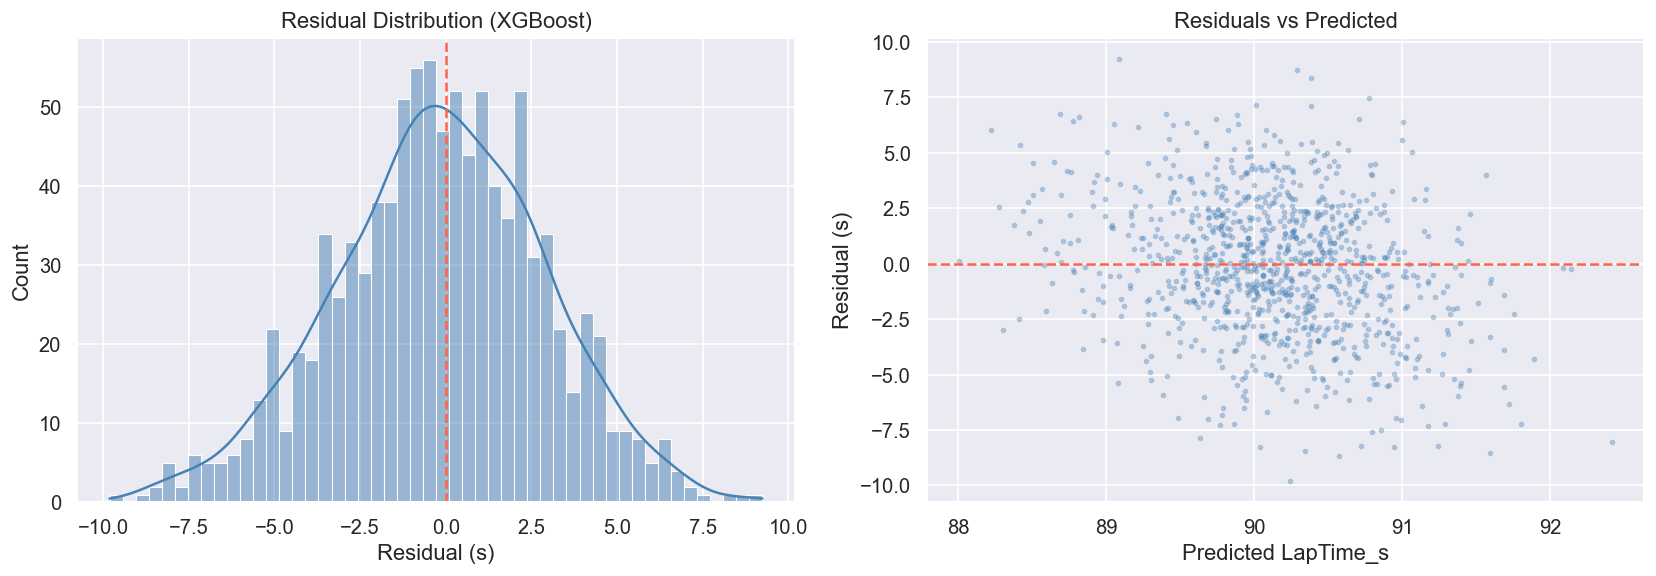


Mean residual : -0.1800 s (bias)
Std  residual : 3.0579 s


In [16]:
residuals = y_test.values - y_pred_xgb
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of residuals
sns.histplot(residuals, kde=True, bins=50, ax=axes[0], color="steelblue")
axes[0].axvline(0, color="tomato", linewidth=1.5, linestyle="--")
axes[0].set_title("Residual Distribution (XGBoost)")
axes[0].set_xlabel("Residual (s)")

# Residuals vs Predicted
axes[1].scatter(y_pred_xgb, residuals, alpha=0.3, s=6, color="steelblue")
axes[1].axhline(0, color="tomato", linewidth=1.5, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted LapTime_s")
axes[1].set_ylabel("Residual (s)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "fig_07_residuals.png", bbox_inches="tight")
plt.show()
print(f"\nMean residual : {residuals.mean():.4f} s (bias)")
print(f"Std  residual : {residuals.std():.4f} s")


## 10. Conclusions & Next Steps

### Key Findings
1. **Rolling pace features** (`roll_laptime_3`, `roll_laptime_5`) are the strongest  
   predictors of a driver's next lap time, validating the signal-extraction rationale.  
2. **Tyre degradation slope** and **normalised tyre life** surface non-linear wear effects  
   that Linear Regression cannot capture — contributing to XGBoost's MAE improvement.  
3. **Weather and historical points** add marginal predictive power individually but  
   provide important cross-session context for circuit-specific generalisation.

### Next Steps (Priority Order)
1. **Unit Tests** (`pytest`) on `rolling_pace.py`, `tyre_degradation.py`, and `encoding.py`  
   targeting ≥80% coverage (as per project standards).  
2. **SHAP Explainability** — replace Gain importance with SHAP values for additive,  
   per-prediction explanations (already in dev dependencies).  
3. **LightGBM Benchmark** — per `@data-science-expert`, always benchmark XGBoost vs  
   LightGBM on tabular data before declaring a winner.  
4. **Per-Circuit Evaluation** — decompose MAE by `EventName` to detect circuit-specific  
   model weaknesses (urban vs. permanent tracks).  
5. **Model Serialisation** — export best XGBoost model as `models/xgboost_pace_v1.json`  
   for inference in the production pipeline.


In [17]:
print("Notebook complete ✓")
print(f"Reports saved to: reports/")
print(f"  fig_01_laptime_distribution.png")
print(f"  fig_02_tyre_degradation.png")
print(f"  fig_03_correlation_matrix.png")
print(f"  fig_04_points_vs_laptime.png")
print(f"  fig_05_predicted_vs_actual.html  (interactive)")
print(f"  fig_06_feature_importance.html   (interactive)")
print(f"  fig_07_residuals.png")


Notebook complete ✓
Reports saved to: reports/
  fig_01_laptime_distribution.png
  fig_02_tyre_degradation.png
  fig_03_correlation_matrix.png
  fig_04_points_vs_laptime.png
  fig_05_predicted_vs_actual.html  (interactive)
  fig_06_feature_importance.html   (interactive)
  fig_07_residuals.png
